A centroid (bottom=0.10, top=0.80): x=2.0000, y=0.3758
B centroid (bottom=0.00, top=1.00): x=3.0000, y=0.3333
A+B centroid (A:0.1-0.8, B:0-1): x=2.5714, y=0.3636
A centroid (bottom=0.00, top=0.10): x=2.0000, y=0.0491
B centroid (bottom=0.00, top=0.50): x=3.0000, y=0.2222
A+B centroid (A:0-0.1, B:0-0.5): x=2.8294, y=0.2020
A centroid (bottom=0.00, top=0.10): x=2.0000, y=0.0491
B centroid (bottom=0.00, top=0.50): x=3.0000, y=0.2222
A+B centroid (A:0-0.1, B:0-0.5): x=2.8294, y=0.2020
A centroid (bottom=0.00, top=0.10): x=2.0000, y=0.0491
A+B centroid (A:0-0.1, B:0-0): x=2.0000, y=0.0491


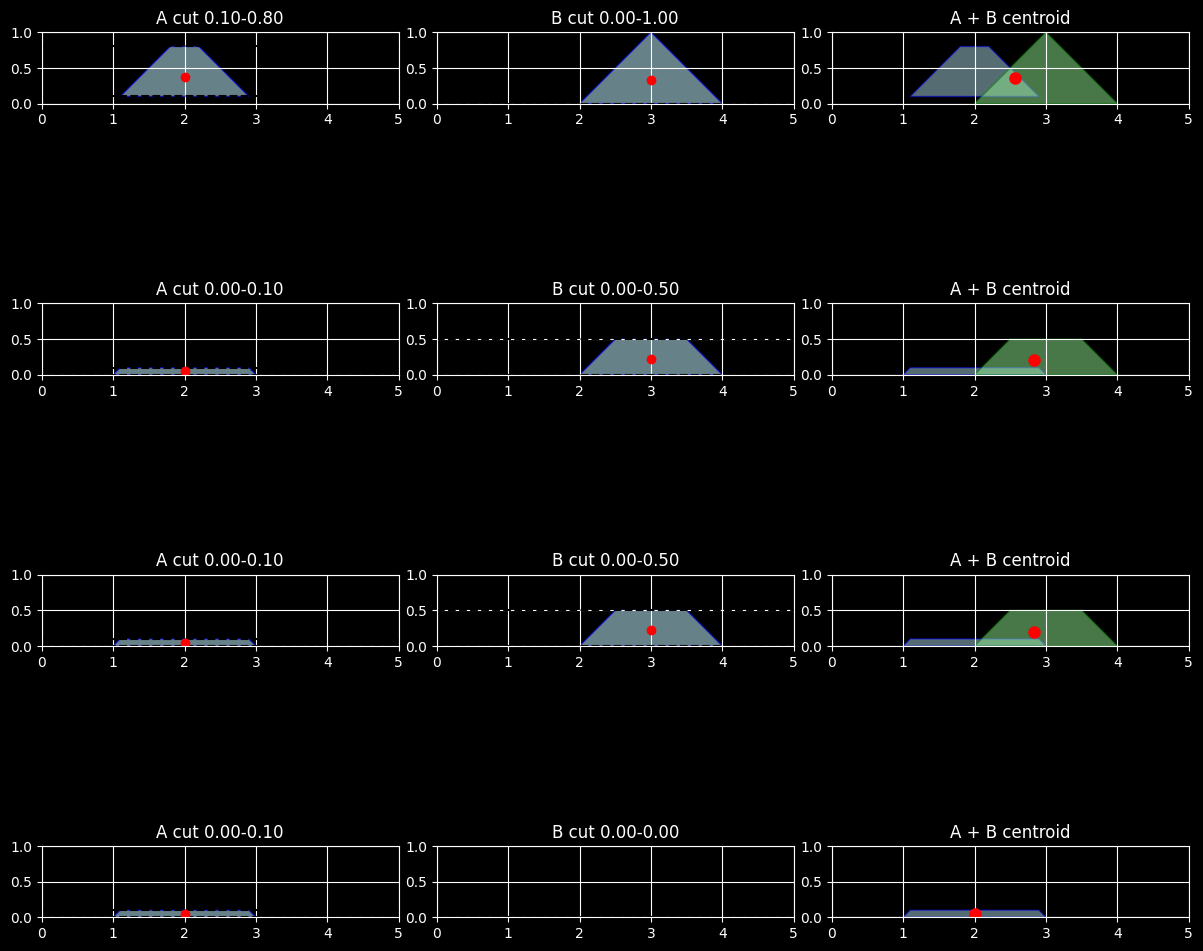

In [39]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from shapely.geometry import Polygon as ShapelyPolygon
from shapely.ops import unary_union

# ==============================
# ТРЕУГОЛЬНИКИ
# ==============================
triangleA = [[1,0],[2,1],[3,0]]
triangleB = [[2,0],[3,1],[4,0]]

# ==============================
# ЯВНЫЕ ВЕРХНИЕ И НИЖНИЕ СРЕЗЫ
# ==============================
bottom_cuts_A = [0.1, 0, 0, 0]
top_cuts_A    = [0.8, 0.1, 0.1, 0.1]

bottom_cuts_B = [0, 0, 0, 0]
top_cuts_B    = [1, 0.5, 0.5, 0]

# ==============================
# ГЕОМЕТРИЯ
# ==============================
def slice_band(triangle, bottom, top):
    """Создаёт полосу треугольника между bottom и top с правильным обходом"""
    intersections_bottom = []
    intersections_top = []
    inside = []

    # ищем точки на сторонах
    for i in range(3):
        p1, p2 = triangle[i], triangle[(i+1)%3]

        # точки внутри диапазона
        if bottom <= p1[1] <= top:
            inside.append(p1)

        # пересечение с bottom
        if (p1[1] - bottom)*(p2[1]-bottom) < 0:
            t = (bottom - p1[1])/(p2[1]-p1[1])
            x = p1[0] + t*(p2[0]-p1[0])
            intersections_bottom.append([x, bottom])

        # пересечение с top
        if (p1[1] - top)*(p2[1]-top) < 0:
            t = (top - p1[1])/(p2[1]-p1[1])
            x = p1[0] + t*(p2[0]-p1[0])
            intersections_top.append([x, top])

    # строим обход: снизу слева направо, сверху справа налево
    bottom_line = sorted(intersections_bottom + [p for p in inside if p[1]==bottom], key=lambda p: p[0])
    top_line    = sorted(intersections_top + [p for p in inside if p[1]==top], key=lambda p: -p[0])

    middle_points = [p for p in inside if bottom < p[1] < top]

    band = bottom_line + middle_points + top_line
    # удаляем дубликаты
    band_unique = []
    for p in band:
        if p not in band_unique:
            band_unique.append(p)
    return band_unique

def centroid(points):
    if len(points) < 3: return None
    poly = ShapelyPolygon(points)
    if poly.is_valid: return [poly.centroid.x, poly.centroid.y]
    return None

def combined_centroid(polys):
    shapes = []
    for p in polys:
        if len(p) >= 3:
            poly = ShapelyPolygon(p)
            if poly.is_valid: shapes.append(poly)
    if not shapes: return None
    comb = unary_union(shapes)
    return [comb.centroid.x, comb.centroid.y]

# ==============================
# РИСОВАНИЕ
# ==============================
def draw_triangle(ax, triangle, bottom, top, name="A"):
    band = slice_band(triangle, bottom, top)
    tri = Polygon(triangle, edgecolor='black', facecolor='none', linewidth=2)
    ax.add_patch(tri)
    ax.axhline(bottom, color='k', linestyle='--')
    ax.axhline(top, color='k', linestyle='--')
    c = None
    if len(band) >= 3:
        poly = Polygon(band, edgecolor='blue', facecolor='lightblue', alpha=0.6)
        ax.add_patch(poly)
        c = centroid(band)
        if c: ax.plot(c[0], c[1], 'ro', markersize=6)
    if c:
        print(f"{name} centroid (bottom={bottom:.2f}, top={top:.2f}): x={c[0]:.4f}, y={c[1]:.4f}")
    return band

def draw_combined(ax, tA, tB, bA, tA_, bB, tB_):
    bandA = slice_band(tA, bA, tA_)
    bandB = slice_band(tB, bB, tB_)
    if len(bandA) >= 3: ax.add_patch(Polygon(bandA, edgecolor='blue', facecolor='lightblue', alpha=0.5))
    if len(bandB) >= 3: ax.add_patch(Polygon(bandB, edgecolor='green', facecolor='lightgreen', alpha=0.5))
    c = combined_centroid([bandA, bandB])
    if c:
        ax.plot(c[0], c[1], 'ro', markersize=8)
        print(f"A+B centroid (A:{bA}-{tA_}, B:{bB}-{tB_}): x={c[0]:.4f}, y={c[1]:.4f}")

# ==============================
# MAIN
# ==============================
def main():
    fig, axes = plt.subplots(4,3,figsize=(12,12))
    for i in range(4):
        axA, axB, axAB = axes[i]
        draw_triangle(axA, triangleA, bottom_cuts_A[i], top_cuts_A[i], name="A")
        draw_triangle(axB, triangleB, bottom_cuts_B[i], top_cuts_B[i], name="B")
        draw_combined(axAB, triangleA, triangleB, bottom_cuts_A[i], top_cuts_A[i], bottom_cuts_B[i], top_cuts_B[i])
        for ax in [axA, axB, axAB]:
            ax.set_xlim(0,5)
            ax.set_ylim(0,1)
            ax.set_aspect('equal')
            ax.grid(True)
        axA.set_title(f"A cut {bottom_cuts_A[i]:.2f}-{top_cuts_A[i]:.2f}")
        axB.set_title(f"B cut {bottom_cuts_B[i]:.2f}-{top_cuts_B[i]:.2f}")
        axAB.set_title("A + B centroid")
    plt.tight_layout()
    plt.show()

if __name__=="__main__":
    main()